In [12]:
#maps of detections and candidates for the Creek Fire (Fig 2, S5)
#runs on NASA MAAP ADE, reading VIIRS swaths from EarthData Cloud

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
import pandas as pd
import os
import datetime as dt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gs
import matplotlib.dates as mdates
import fsspec
import earthaccess

In [ ]:
#user define global variables

ROOT = '/projects/my-public-bucket/'

NAME = 'creek' #folder name for outputs
extent = [-119.6, 36.9, -118.9, 37.6] #creek

output_dir = '/projects/my-public-bucket/viirs/'
input_dir = '/projects/shared-buckets/coffield/viirs/'

In [34]:
#read in previously extracted VIIRS known & candidate detections for the Creek Fire (scripts #1-3)
dets = pd.read_parquet(input_dir + 'outputs/western_us/joined_dets_2020.parquet')
dets = dets[dets.name=='CREEK']
dets

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,j,vza,sza,...,frp,frp_old,dist_m13b,geometry,satellite,index_right,fireid,startdate,enddate,name
250773,-119.270966,36.989986,8.0,n,2020-09-16,09:54,2020-09-16 09:54:00+00:00,3618.0,11.17820,131.15000,...,1.615285,1.615285,NaN,b'\x01\x01\x00\x00\x00\xfd\x14\xc7\x81W\xd1]\x...,SNPP,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
250774,-119.270310,36.990383,8.0,n,2020-09-15,19:54,2020-09-15 19:54:00+00:00,6045.0,52.91200,34.39000,...,5.950140,5.950140,NaN,b'\x01\x01\x00\x00\x00\x08rP\xc2L\xd1]\xc0\xd7...,SNPP,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
250775,-119.275500,36.990780,8.0,n,2020-09-16,09:54,2020-09-16 09:54:00+00:00,3617.0,11.15150,131.15000,...,3.597847,3.597847,NaN,b'\x01\x01\x00\x00\x00\x12\x83\xc0\xca\xa1\xd1...,SNPP,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
250776,-119.270400,36.992203,8.0,n,2020-09-15,10:12,2020-09-15 10:12:00+00:00,4494.0,33.56130,128.20000,...,13.232900,13.232900,NaN,b'\x01\x01\x00\x00\x00\xa85\xcd;N\xd1]\xc0\x1e...,SNPP,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
250777,-119.271990,36.992233,9.0,h,2020-09-15,21:36,2020-09-15 21:36:00+00:00,1291.0,44.48160,41.91000,...,88.511513,88.511513,NaN,b'\x01\x01\x00\x00\x00\xb3\xb5\xbeHh\xd1]\xc0\...,SNPP,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873857,-119.165764,37.553604,8.0,n,2020-11-03,09:00,2020-11-03 09:00:00+00:00,1122.0,46.08230,150.81999,...,0.687182,0.687182,NaN,b'\x01\x01\x00\x00\x00\xaa\xb6\x9b\xe0\x9b\xca...,NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
873858,-119.078804,37.554460,8.0,n,2020-11-16,10:00,2020-11-16 10:00:00+00:00,3954.0,20.14210,144.12000,...,0.808999,0.808999,NaN,b'\x01\x01\x00\x00\x00\xd1\xb2\xee\x1f\x0b\xc5...,NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
873859,-119.158820,37.556786,8.0,n,2020-11-05,21:24,2020-11-05 21:24:00+00:00,1483.0,41.06680,59.39000,...,4.264699,4.264699,NaN,b'\x01\x01\x00\x00\x00\xd9|\\\x1b*\xca]\xc0ro~...,NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
873860,-119.164820,37.559460,8.0,n,2020-11-05,10:06,2020-11-05 10:06:00+00:00,4215.0,27.10520,140.89000,...,2.125922,2.125922,NaN,b'\x01\x01\x00\x00\x00\x83n/i\x8c\xca]\xc0\xc8...,NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK


In [73]:
#three s3 swath products needed: geolocation (03IMG), science data (02IMG), L2 fire product (14IMG)
products = {'SNPP':['VNP03IMG','VNP02IMG','VNP14IMG'], 
            'NOAA20':['VJ103IMG','VJ102IMG','VJ114IMG']}

s3_fsspec = fsspec.filesystem("s3", profile="maap-data-reader", requester_pays=True) #optional, for direct reader access to LPDAAC for L2 products; requires profile setup

<h3>Collect imagery for 4 timestamps for Creek Fire example (Fig 2)</h3>

In [81]:
start = '2020-09-05' #start date is inclusive, run one month at a time
end = '2020-09-09' #end date is exclusive

In [82]:
#run once for SNPP and once for NOAA20 (SNPP shown in paper)
sat = 'NOAA20'
print(sat, '-------')

files = {}

earthaccess.login(strategy='netrc') #for LAADS access - every hour

#Level1 data from LAADS ------
#geolocation 03IMG
results = earthaccess.search_data(
    short_name=products[sat][0],
    bounding_box=(extent[0],extent[1],extent[2],extent[3]),
    temporal=(start, end),
    count=500)
files[products[sat][0]] = earthaccess.open(results)

#science data 02IMG
results = earthaccess.search_data(
    short_name=products[sat][1],
    bounding_box=(extent[0],extent[1],extent[2],extent[3]),
    temporal=(start, end),
    count=500)
files[products[sat][1]] = earthaccess.open(results)

NOAA20 -------
Granules found: 12
Opening 12 granules, approx size: 1.8 GB


QUEUEING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

Granules found: 12
Opening 12 granules, approx size: 2.09 GB


QUEUEING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

In [83]:
#subset to only 4 files of interest for figure

#Sep 5 249 21:18
#Sep 6 250 21:00
#Sep 7 251 20:42
#Sep 8 252 20:24

timestamps = ['A2020249.2118','A2020250.2100','A2020251.2042','A2020252.2024'] #SNPP shots
timestamps = ['A2020249.2030','A2020250.2012','A2020251.2130','A2020252.2112'] #NOAA20 shots

for key in files:
    files[key] = [f for f in files[key] if any(t in str(f) for t in timestamps)]

files

{'VJ103IMG': [<File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VJ103IMG/VJ103IMG.A2020249.2030.021.2021068095824.nc>,
  <File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VJ103IMG/VJ103IMG.A2020250.2012.021.2021068111153.nc>,
  <File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VJ103IMG/VJ103IMG.A2020251.2130.021.2021068122037.nc>,
  <File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VJ103IMG/VJ103IMG.A2020252.2112.021.2021068124404.nc>],
 'VJ102IMG': [<File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VJ102IMG/VJ102IMG.A2020249.2030.021.2021068192552.nc>,
  <File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VJ102IMG/VJ102IMG.A2020250.2012.021.2021068200757.nc>,
  <File-like object HTTPFileSystem, https://data.laadsdaac.earthdatacloud.nasa.gov/prod

In [70]:
def scale_bar(ax, length=None, location=(0.15, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    credit: https://stackoverflow.com/questions/32333870/how-can-i-show-a-km-ruler-on-a-cartopy-matplotlib-plot
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(ccrs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = ccrs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0]
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby+600, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom')

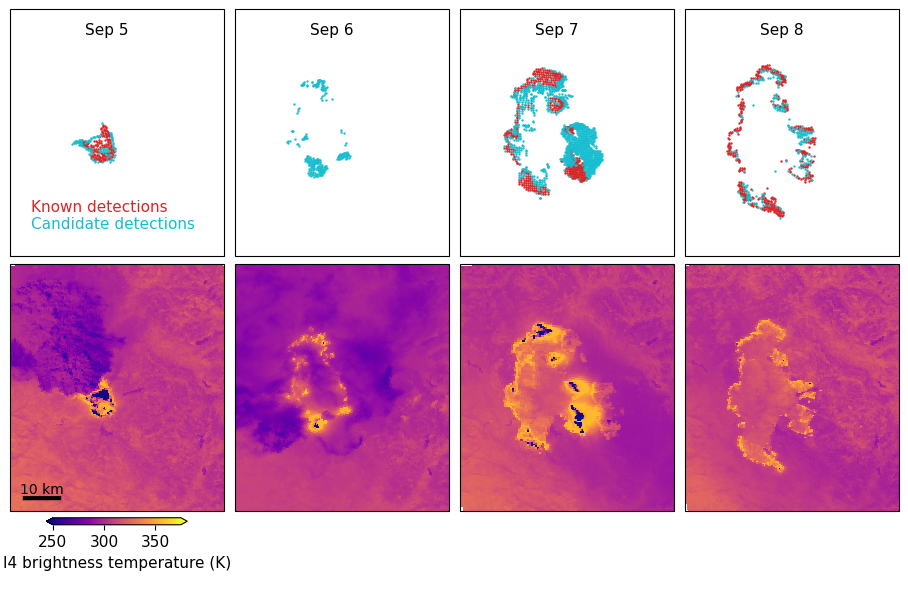

In [84]:
fig, axes = plt.subplots(3,4, subplot_kw={'projection': ccrs.Miller()}, gridspec_kw={'height_ratios':[3,3,1]}, constrained_layout=True, figsize=(9,6))
axes = axes.flatten()

blue = mpl.colormaps['tab10'](9) 
red = mpl.colormaps['tab10'](3) 


#first row: candidate plus known dets
a = 0
for t in timestamps:
    t = dt.datetime.strptime(t, 'A%Y%j.%H%M').replace(tzinfo=dt.timezone.utc)

    subset = dets[dets.acq_datetime == t]
    
    known = subset[subset.fire_mask > 6]
    axes[a].scatter(known.longitude, known.latitude, color=red, s=0.5, transform=ccrs.Geodetic())
    
    cands = subset[subset.confidence=='x']
    axes[a].scatter(cands.longitude, cands.latitude, color=blue, s=0.5, transform=ccrs.Geodetic())
    
    axes[a].set_extent([extent[0],extent[2],extent[1],extent[3]])
    axes[a].annotate(t.strftime('%b %-d'), xy=(0.35, 0.9),  size=11, xycoords=axes[a].transAxes)

    a = a+1
    
axes[0].annotate('Candidate detections', xy=(0.1, 0.11),  size=11, xycoords=axes[0].transAxes, color=blue)
axes[0].annotate('Known detections', xy=(0.1, 0.18),  size=11, xycoords=axes[0].transAxes, color=red)


#second row: i4 imagery

for i in range(len(timestamps)):

    #open 03IMG geolocation
    geo = xr.open_dataset(files[products[sat][0]][i], engine='h5netcdf', group='geolocation_data')
    lon = geo['longitude'][:]
    lat = geo['latitude'][:]

    scene = (lon > extent[0]) & (lon < extent[2]) & (lat > extent[1]) & (lat < extent[3])

    #crop down the datasets for memory 
    indices = np.where(scene)
    if len(indices[0])==0 or len(indices[1])==0:
        print('no data in scene')
        continue
    x0 = indices[0].min()
    x1 = indices[0].max()
    y0 = indices[1].min()
    y1 = indices[1].max()

    lon = lon[x0:x1, y0:y1]
    lat = lat[x0:x1, y0:y1]

    #open 02IMG science data, i4 band
    data = xr.open_dataset(files[products[sat][1]][i], engine='h5netcdf', group='observation_data')
    data = data.sel(number_of_lines=slice(x0,x1), number_of_pixels=slice(y0,y1))

    i4 = data['I04'] #xarray already encodes the scale factor and offset
    scale = data.I04.encoding['scale_factor']
    offset = data.I04.encoding['add_offset']
    i4 = (i4[:,:] - offset) / scale #return to raw values to use lookup table to temperature
    i4 = i4.astype(int)
    i4_bt = data['I04_brightness_temperature_lut'][:]
    i4_bt = i4_bt[i4]
    
    plot = axes[a].pcolormesh(lon, lat, i4_bt, vmin=250, vmax=375, transform=ccrs.PlateCarree(), cmap='plasma')
    axes[a].set_extent([extent[0],extent[2],extent[1],extent[3]])
                                                                    
    a = a+1
    
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.65, pad=-1, extend='both', ax=axes[8])
cbar.ax.tick_params(labelsize=11)
cbar.set_label('I4 brightness temperature (K)', size=11)
scale_bar(axes[4], 10)
axes[8].axis('off')
axes[9].axis('off')
axes[10].axis('off')
axes[11].axis('off')
plt.savefig(f'/projects/my-public-bucket/figures/fig2_creek_{sat}.png', dpi=300)

<h3>Plot each timestamp I4 imagery + candidates map + bar chart for Creek fire (Fig S5) SNPP

In [85]:
start = '2020-09-05'
end = '2020-09-18'

In [86]:
sat = 'SNPP'
print(sat, '-------')

files = {}

earthaccess.login(strategy='netrc') #for LAADS access - every hour

#Level1 data from LAADS ------
#geolocation 03IMG
results = earthaccess.search_data(
    short_name=products[sat][0],
    bounding_box=(extent[0],extent[1],extent[2],extent[3]),
    temporal=(start, end),
    count=500)
files[products[sat][0]] = earthaccess.open(results)

#science data 02IMG
results = earthaccess.search_data(
    short_name=products[sat][1],
    bounding_box=(extent[0],extent[1],extent[2],extent[3]),
    temporal=(start, end),
    count=500)
files[products[sat][1]] = earthaccess.open(results)

SNPP -------
Granules found: 38
Opening 38 granules, approx size: 5.71 GB


QUEUEING TASKS | :   0%|          | 0/38 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/38 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/38 [00:00<?, ?it/s]

Granules found: 38
Opening 38 granules, approx size: 6.68 GB


QUEUEING TASKS | :   0%|          | 0/38 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/38 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/38 [00:00<?, ?it/s]

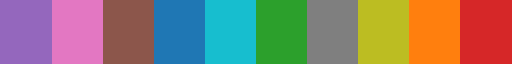

In [87]:
#define colormap for fire mask
newcolors = [mpl.colormaps['tab10'](c) for c in [4,6,5,0,9,2,7,8,1,3]]
newcmp = ListedColormap(newcolors)
newcmp

In [ ]:
for i in range(2,len(files[products[sat][0]])):
    timestamp = '.'.join(files[products[sat][0]][i].url.split('.')[-5:-3]) #e.g., A2020250.0942
    timestamp = dt.datetime.strptime(timestamp, 'A%Y%j.%H%M').replace(tzinfo=dt.timezone.utc)
    print(timestamp)
    
    #open 03IMG geolocation
    geo = xr.open_dataset(files[products[sat][0]][i], engine='h5netcdf', group='geolocation_data')
    lon = geo['longitude'][:]
    lat = geo['latitude'][:]

    scene = (lon > extent[0]) & (lon < extent[2]) & (lat > extent[1]) & (lat < extent[3])

    #crop down the datasets for memory 
    indices = np.where(scene)
    if len(indices[0])==0 or len(indices[1])==0:
        print('no data in scene')
        continue
    x0 = indices[0].min()
    x1 = indices[0].max()
    y0 = indices[1].min()
    y1 = indices[1].max()

    lon = lon[x0:x1, y0:y1]
    lat = lat[x0:x1, y0:y1]

    #open 02IMG science data, i4 band
    data = xr.open_dataset(files[products[sat][1]][i], engine='h5netcdf', group='observation_data')
    data = data.sel(number_of_lines=slice(x0,x1), number_of_pixels=slice(y0,y1))

    i4 = data['I04'] #xarray already encodes the scale factor and offset
    scale = data.I04.encoding['scale_factor']
    offset = data.I04.encoding['add_offset']
    i4 = (i4[:,:] - offset) / scale #return to raw values to use lookup table to temperature
    i4 = i4.astype(int)
    i4_bt = data['I04_brightness_temperature_lut'][:]
    i4_bt = i4_bt[i4]

    #get corresponding L2 dets previously extracted
    subset = dets[dets.acq_datetime == timestamp]


    fig = plt.figure(figsize=(12,4), constrained_layout=True)
    grid = gs.GridSpec(1,3, width_ratios=[1.1,1.1,0.9])
    ax = plt.subplot(grid[0], projection = ccrs.Miller())
    ax2 = plt.subplot(grid[1], projection = ccrs.Miller())
    ax3 = plt.subplot(grid[2])

    #left panel temperature map
    ax.set_extent([extent[0],extent[2],extent[1],extent[3]])
    plot = ax.pcolormesh(lon, lat, i4_bt, vmin=250, vmax=375, transform=ccrs.PlateCarree(), cmap='plasma')
    #cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.65, pad=0, extend='both', ax=ax)
    #cbar.ax.tick_params(labelsize=11)
    #cbar.set_label('I4 brightness temperature (K)', size=12)
    ax.set_title((timestamp - dt.timedelta(hours=7)).strftime('%b %-d %H:%M PDT') )
    ax.annotate('I4 temperature', xy=(0.25, 0.9),  size=12, xycoords=ax.transAxes,color='white')

    #middle panel detections map
    ax2.set_extent([extent[0],extent[2],extent[1],extent[3]])
    ax2.scatter(subset.longitude, subset.latitude, c=newcmp(subset.fire_mask.astype(int)), s=1, transform=ccrs.Geodetic(), cmap=newcmp)
    ax2.annotate('Fire mask', xy=(0.35, 0.9),  size=12, xycoords=ax2.transAxes)
    scale_bar(ax2, 10)
    
    #right panel barchart
    values, counts = np.unique(subset['fire_mask'], return_counts=True)
    fraction_missing = counts[values<7].sum() / counts.sum()
    colors = [newcmp(int(c)) for c in values]
    ax3.bar(values, counts, color=colors)
    labels = ['0 not-processed', '1 bowtie', '2 glint', '3 water','4 clouds',
              '5 clear land','6 unclassified fire pixel','7 low confidence fire pixel',
              '8 nominal confidence fire pixel','9 high confidence fire pixel']
    ax3.set_xlim((-0.8,9.8))
    ax3.set_xticks(range(10))
    ax3.set_xticklabels(labels, rotation=45, ha='right')
    ax3.set_ylabel('Number of pixels')    
    ax3.annotate('{:.1f}% candidates'.format(fraction_missing*100), xy=(0.07, 0.88),  size=11, xycoords=ax3.transAxes)
    ax3.plot((0.05,0.68), (0.85, 0.85), transform=ax3.transAxes, c='k', linewidth=1)

    plt.subplots_adjust(wspace=0.3)
    plt.savefig(f'/projects/my-public-bucket/figures/creek/figS5_{timestamp.strftime("A%Y%j.%H%M")}_{sat}.png', bbox_inches='tight', dpi=200)
    plt.close()